# Task 1: Exploratory Data Analysis (EDA) on Titanic Dataset

## Objective
The goal of this project is to perform data cleaning, analysis, and visualization on the Titanic dataset to extract meaningful insights.

## Dataset
Titanic-Dataset.csv

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set(style="whitegrid")

In [2]:
# Load dataset
df = pd.read_csv('../data/Titanic-Dataset.csv')

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Basic Information

In this step, we check dataset structure, data types, and summary statistics.

In [3]:
# Dataset info
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Data Cleaning

Handling missing values in Age, Cabin, and Embarked columns.

In [4]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

# Verify again
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Survival Count

Check how many passengers survived vs not survived.

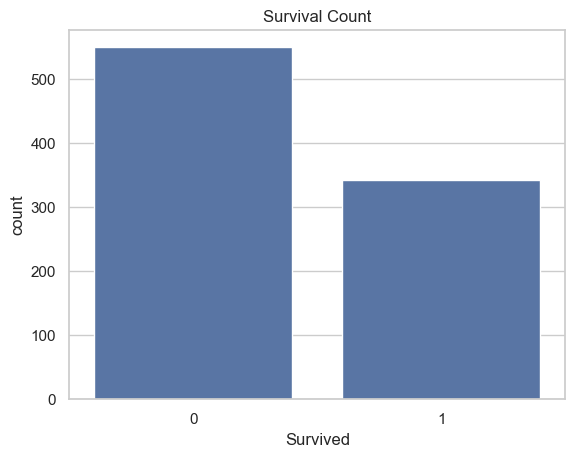

In [6]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.savefig('../images/survival_count.png')
plt.show()

## Gender Distribution

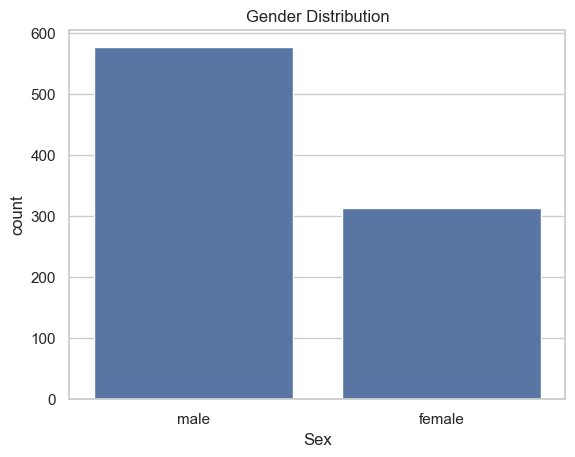

In [7]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.savefig('../images/gender_distribution.png')
plt.show()

## Age Distribution

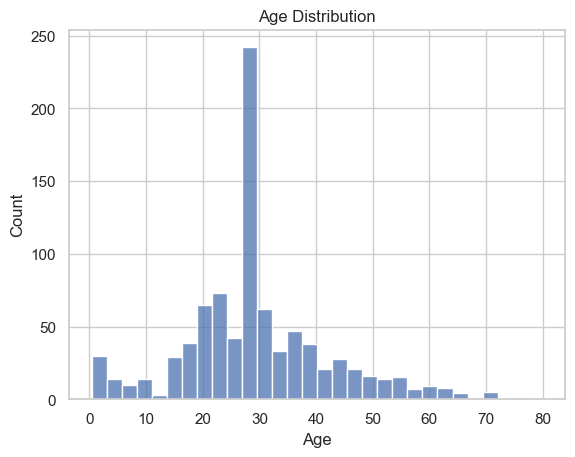

In [8]:
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.savefig('../images/age_distribution.png')
plt.show()

## Survival by Gender

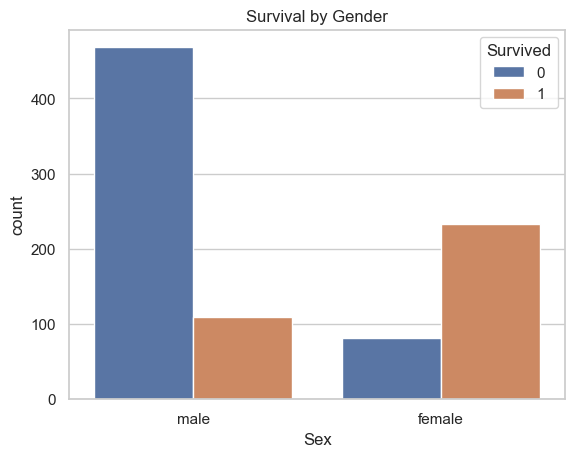

In [9]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.savefig('../images/survival_gender.png')
plt.show()

## Correlation Heatmap

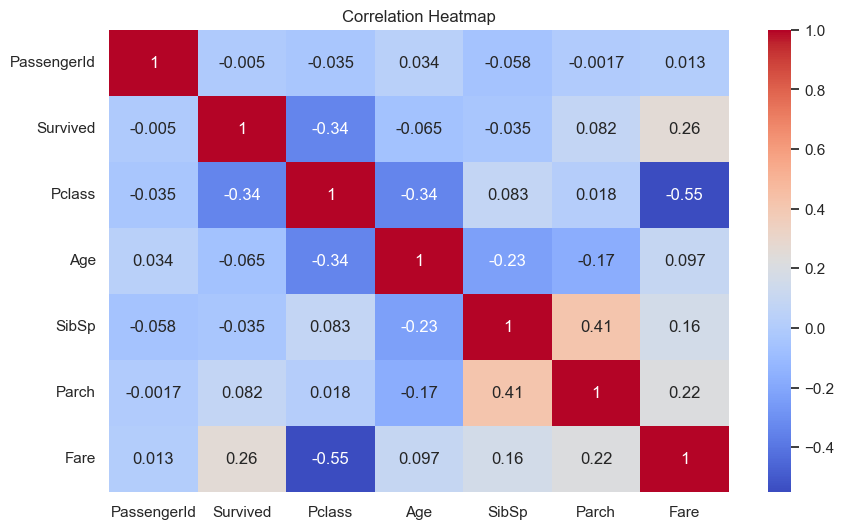

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig('../images/correlation_heatmap.png')
plt.show()

## Key Insights

- Majority of passengers did not survive.
- Female passengers had higher survival rates compared to males.
- Most passengers were between age 20-40.
- Passenger class (Pclass) has a strong impact on survival.
- Fare shows some correlation with survival.

## Conclusion

The analysis reveals important factors influencing survival such as gender, passenger class, and fare. Data visualization helped in understanding patterns and relationships in the dataset.